# **Data Analysis for _A Comparative Analysis of Content Across Major Streaming Services_**

#### **Authors**: Karis Park and Elise Huhn

### **Research Questions:**

1. Are there significant differences in genre distribution across streaming platforms?
2. Is there a difference between the platforms in their balance between movies and television shows?
3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?

## **Descriptive Statistics**

In [1]:
#Library Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import chi2_contingency, chi2, ttest_ind

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
#Read in the datasets
streaming_full = pd.read_csv("Data/streaming_combines.csv")

In [3]:
streaming_full.sample(10)

,movie_or_serie,title,release_year,duration_seconds,channel_streaming,action,comedy,adventure,animation,anime,drama,international,kids,horror
8586,Movie,John Carter,2012,133 min,netflix,1,0,1,0,0,0,0,0,0
4688,TV Show,Dolly Parton's Heartstrings,2019,1 Season,netflix,0,0,0,0,0,0,0,0,0
14679,Movie,Penance Lane,2020,84 min,amazon_prime,0,0,0,0,0,0,0,0,1
13193,TV Show,Beverly Hills 90210,1990,10 Seasons,hulu,0,0,0,0,0,1,0,0,0
3994,Movie,Action Replayy,2010,129 min,netflix,0,0,0,0,0,0,1,0,0
15748,Movie,Frontier Outlaws,1944,57 min,amazon_prime,0,0,0,0,0,0,0,0,0
459,Movie,Surviving the Mount St. Helens Disaster,2020,44 min,disney_plus,0,0,0,0,0,0,0,0,0
22715,Movie,Flawless,1999,111 min,amazon_prime,0,1,0,0,0,1,0,0,0
20710,Movie,Soledad,2014,84 min,amazon_prime,0,0,0,0,0,1,0,0,0
5287,TV Show,Jailbirds,2019,1 Season,netflix,0,0,0,0,0,0,0,0,0


In [4]:
#show overall numerical summaries
streaming_full.describe()

,release_year,action,comedy,adventure,animation,anime,drama,international,kids,horror
count,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000
mean,2010.811244,0.140838,0.160492,0.080094,0.048961,0.028698,0.205583,0.203235,0.079963,0.070050
std,15.401142,0.347862,0.367070,0.271444,0.215791,0.166960,0.404136,0.402415,0.271243,0.255236
min,1920.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Interpretation:** These numerical summaries show that the oldest screen media in out dataset was released in 1920, whereas the most recent was released in 2021. The median release date is 2016 and the mean is 2010, which indicates that the majority of the motion pictures were released after the 2000s. The numerical summaries for the other quatitative variables are less useful in determining their distributions because they are binary variables. 

In [5]:
#Frequency of each Streaming Service
streaming_full["channel_streaming"].value_counts()

channel_streaming
amazon_prime    9668
netflix         8807
hulu            3073
disney_plus     1450
Name: count, dtype: int64

**Interpretation:** Amazon Prime is the streaming service with the most amount of observations (9668). The second most frequent is Netflix (8807), and the third is Hulu (3073). The streaming service with the least amount of observations is Disney Plus (1450), which has less than one-sixth the amount of observations as Amazon Prime. Thus, our data is not evantly distributed among the different streaming services. 

In [6]:
#Frequency of Movies and TV Shows
streaming_full["movie_or_serie"].value_counts()

movie_or_serie
Movie      16481
TV Show     6517
Name: count, dtype: int64

**Interpretation:** There are 2.5 times as many movies in the dataset as there are TV shows. So, our data is not evenly distributed among the two different types of motion pictures. 

In [7]:
#Total Counts of Each Genre
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

print("Frequency of Each Genre:")
streaming_full[genres].sum().sort_values(ascending=False)

Frequency of Each Genre:


drama            4728
international    4674
comedy           3691
action           3239
adventure        1842
kids             1839
horror           1611
animation        1126
anime             660
dtype: int64

**Interpretation:** The genre with the most observations is drama. Anime is the genre with the least amount of observations. There are about 7 times as many drama observations as there are amine observations. There are a similar numer of drama and international observations. Similarly, there are a similar number of comedy and action observations as well as a similar numer of adventure, kids, horror, and animation movies. The genres are not evenly distributed throughout the dataset. 

### **Documentation**

First, we documented the numerical summaries of all of the quantitative varibles. This was most useful for determining the distribution of the release years for the screen media. Since each genre column is bianary, we displayed the frequency of each genre across all streaming services to better determine the genre distribution. Then, we provided the frequencies for both the categorical variables of channel_streaming and movie_or_serie to show their distributions. 

These numerical representations allowed us to understand the distributions of out variables to begin investigating our research questions. Namely we focused on the distribution of genres and streaming services to investigate our first research question: "Are there significant differences in genre distribution across streaming platforms?" We also investigated the distributions of movies and TV shows for our second research question: "Is there a difference between the platforms in their balance between movies and television shows?" And finally the combination of all of the sumerical summaries will aid us in determining our thrid research question: "Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?"

## **Inferential Statistics**

In [29]:
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

# 1. Are there significant differences in genre distribution across streaming platforms?
genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
observed_rq1 = genre_table

chi2_stat1, p_value1, dof1, expected1 = chi2_contingency(observed_rq1)

alpha = 0.05
critical_value1 = chi2.ppf(1 - alpha, dof1)

print("RQ1 - CHI-SQUARE TEST: Genre vs Platform")
print("=" * 50)
print(f"Chi-square statistic (χ²): {chi2_stat1:.4f}")
print(f"P-value: {p_value1:.2e}" if p_value1 < 0.001 else f"P-value: {p_value1:.6f}")
print(f"Degrees of freedom: {dof1}")

print(f"\nSignificance level (α): {alpha}")
print(f"Critical value: {critical_value1:.4f}")
print(f"")
if p_value1 < alpha:
    print(f"CONCLUSION: Reject H₀ (p < {alpha})")
    print(
        f"   There IS a significant association between genre and platform."
    )
else:
    print(f"CONCLUSION: Fail to reject H₀ (p ≥ {alpha})")
    print(
        f"   There is NO significant association between genre and platform."
    )

RQ1 - CHI-SQUARE TEST: Genre vs Platform
Chi-square statistic (χ²): 16545.2312
P-value: 0.00e+00
Degrees of freedom: 24

Significance level (α): 0.05
Critical value: 36.4150

CONCLUSION: Reject H₀ (p < 0.05)
   There IS a significant association between genre and platform.


**Interpretation:** To investigate the first question, we used the chi-square test of independence because both variables are categorical. 

- Ho: Genre distribution is independent of streaming platform 
- Ha: Genre distribution is not independent of streaming platform

For all three tests, we chose a significance level of alpha = 0.05, which is the standard threshold for statistics.

Based on the test, we get a p-value of roughly zero, which is expected as our sample size is very large with 23,000 observations. This means that we can reject the null hypothesis that genre distribution is independent of streaming platforms, implying that the difference in genre frequencies that we observe across the different streaming platforms are unlikely to be due to chance. This also supports our graphical findings that platforms differ meaningfully in the types of content they offer. 

In [30]:
# 2. Is there a difference between the platforms in their balance between movies and television shows?
movie_table = pd.crosstab(
    streaming_full["channel_streaming"], streaming_full["movie_or_serie"], margins=True, margins_name='Total'
)

print('CONTINGENCY TABLE: Movie vs TV Show Balance by Platform')
print('=' * 55)
print(movie_table)
print('=' * 55)

chi2_stat2, p_value2, dof2, expected2 = chi2_contingency(movie_table)
critical_value2 = chi2.ppf(1 - alpha, dof2)

print("\nRQ2 - CHI-SQUARE TEST: Movie vs TV Show Balance by Platform")
print("=" *60)
print(f"Chi-square statistic (χ²): {chi2_stat2:.4f}")
print(f"P-value: {p_value2:.2e}" if p_value2 < 0.001 else f"P-value: {p_value2:.6f}")
print(f"Degrees of freedom: {dof2}")

print(f"\nSignificance level (α): {alpha}")
print(f"Critical value: {critical_value2:.4f}")
print(f"")
if p_value2 < alpha:
    print(f"CONCLUSION: Reject H₀ (p < {alpha})")
    print(
        f"   There IS a significant association between Movie/TV Show balance and platform."
    )
else:
    print(f"CONCLUSION: Fail to reject H₀ (p ≥ {alpha})")
    print(
        f"   There is NO significant association between Movie/TV Show balance and platform."
    )

CONTINGENCY TABLE: Movie vs TV Show Balance by Platform
movie_or_serie     Movie  TV Show  Total
channel_streaming                       
amazon_prime        7814     1854   9668
disney_plus         1052      398   1450
hulu                1484     1589   3073
netflix             6131     2676   8807
Total              16481     6517  22998

RQ2 - CHI-SQUARE TEST: Movie vs TV Show Balance by Platform
Chi-square statistic (χ²): 1244.8192
P-value: 1.98e-263
Degrees of freedom: 8

Significance level (α): 0.05
Critical value: 15.5073

CONCLUSION: Reject H₀ (p < 0.05)
   There IS a significant association between Movie/TV Show balance and platform.


**Interpretation:** To investigate the second question, we also used the chi-square test of independence because we're looking at two categorical variables. 

- Ho: The distribution of movies vs TV shows is independent of streaming platform
- Ha: The distribution of movies vs TV shows is not independent of streaming platform

Based on the test, we get a p-value of roughly zero (1.98e-263). This means that we can reject the null hypothesis that Movie/TV Show balance is independent of streaming platforms, implying that the difference in Movie/TV Show balance that we observe across the different streaming platforms are statistically meaningful.

In [26]:
# 3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?
# -> look at: is there a significant difference between movies and tv shows looking at release year?
# group means
print("Group means:")
means = streaming_full.groupby('movie_or_serie')['release_year'].mean()
print(means)

# perform t-test
movies = streaming_full[streaming_full["movie_or_serie"] == "Movie"]["release_year"].dropna()
shows = streaming_full[streaming_full["movie_or_serie"] == "TV Show"]["release_year"].dropna()

t_stat, p_val = ttest_ind(movies, shows)

print("\nT-test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")
print(f"\nInterpretation:")
if p_val < 0.05:
    print(f"p < 0.05: Reject H₀. The methods produce different average scores.")
else:
    print(f"p ≥ 0.05: Fail to reject H₀. No evidence of difference.")

Group means:
movie_or_serie
Movie      2009.224562
TV Show    2014.823845
Name: release_year, dtype: float64

T-test
t-statistic: -25.185
p-value: 0.0000

Interpretation:
p < 0.05: Reject H₀. The methods produce different average scores.


**Interpretation:** To investigate the third question, we used the t-test to compare the mean release year of movies vs TV shows as release year is a quantitative variable. This will provide the foundation for our multivariate analysis, where we build a logistic regression to answer our third research question.

- Ho: There is no difference in average release year between movies and TV shows.
- Ha: There is a difference in average release year between movies and TV shows.

Movies in our dataset have a average release year of approximately 2009, while TV shows have a average release year of approximately 2015. This suggests that TV shows on streaming platforms tend to be more recent than movies, which may reflect the growing trend of original streaming TV series produced in recent years. This is also supported by the t-test where we get a p-value of roughly zero. This suggests that there is an association between the average release year of movies and the average release year of TV shows. However, since we have such a large dataset of 23,000+ observations, although we get that real associations exist, we need to be cautious and conduct more analysis before coming to any conclusions.

### **Documentation**

For the inferential statistics, we conducted hypothesis tests to investigate whether the relationships observed in our descriptive and graphical analyses were statistically significant using a significance level of α = 0.05 for all three tests.

For the first research question, we investigated whether genre distribution is independent of streaming platforms. Since both variables are categorical, we used a chi-square test of independence, with genre as the response variable and streaming platform as the grouping variable. We constructed a contingency table of genre counts by platform to serve as the observed values for the test. Based on the results, we rejected the null hypothesis that genre distribution is independent of streaming platform, concluding that the differences in genre frequencies we observed across platforms are statistically significant and unlikely to be due to chance.

For the second research question, we investigated whether the balance of movies versus TV shows is independent of streaming platform. Similar to the first research question, since both variables are categorical, we used a chi-square test of independence. We constructed a contingency table of content type by platform and ran the test on the observed counts. Based on the results, we rejected the null hypothesis that Movie/TV Show balance is independent of streaming platform, further supporting the association we observed graphically.

For the third research question, we investigated whether there is a difference in mean release year between movies and TV shows, as release year is the one quantitative variable in our dataset and could serve as a distinguishing attribute between content types. Since we were comparing the means of two independent groups, we used an independent samples t-test. We first calculated the group means for each content type, then ran the t-test on the two distributions. Based on the results, we rejected the null hypothesis that movies and TV shows have the same average release year. This finding suggested that release year is a meaningful attribute for distinguishing between content types.

## **Graphical Analysis**

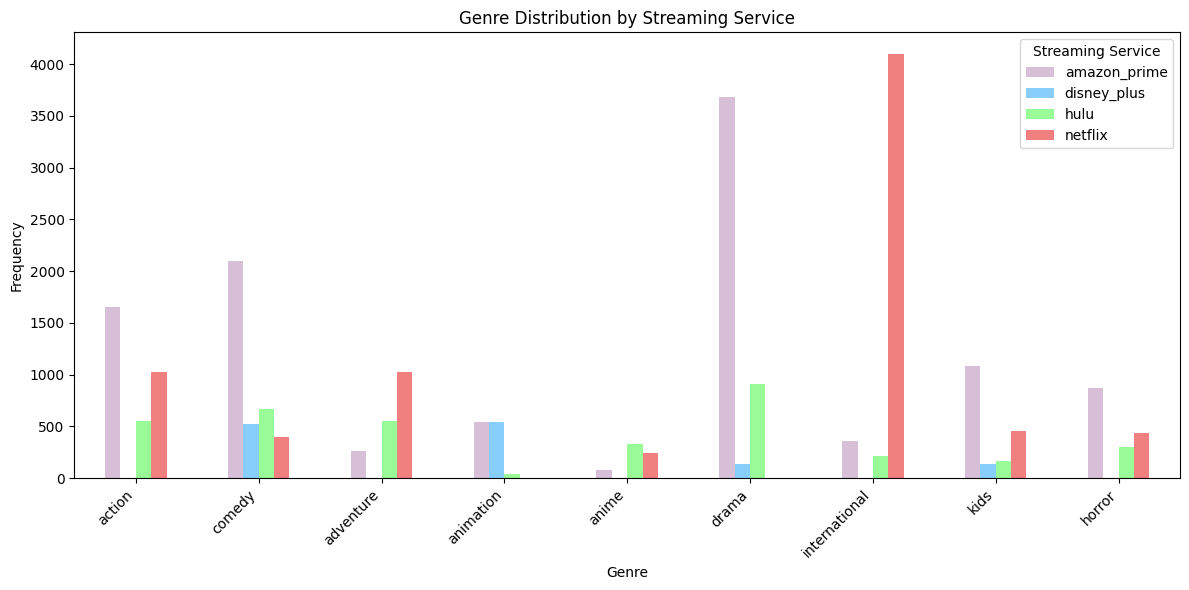

In [164]:
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

#frequency of each genre for each streaming service
genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
genre_df = pd.DataFrame(genre_table)
genre_df = genre_df.T

#create grouped bar chart of genre by streaming service 
genre_df.plot(kind="bar", figsize=(12, 6), color = ["thistle", "lightskyblue", "palegreen", "lightcoral"])
plt.xlabel("Genre")
plt.ylabel("Frequency")
plt.title("Genre Distribution by Streaming Service")
plt.legend(title="Streaming Service")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretation:** The grouped bar chart indicates that Disney Plus doesn't have any obervations for action, adventure, anime, international, nor horror genres. Similarly, Netflix doesn't have any observations for the animation nor drama genres. Both Amazon Prime and Hulu have observations for each genre. There are two clear frequency outliers, which are Amazon Prime in the drama genre and Netflix in the international genre. Both of those bars have unusually high frequency counts.

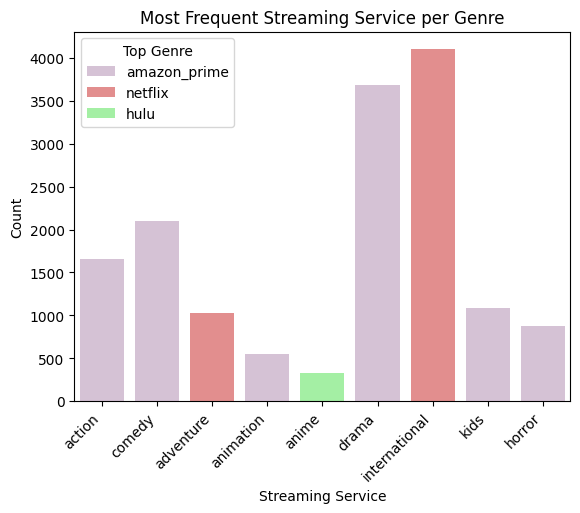

In [163]:
#max frequency of streaming serivce and max genre
top_genres = genre_df.idxmax(axis=1)
top_counts = genre_df.max(axis=1)

#subset data to streaming services with the highest frequency per genre
top_df = pd.DataFrame({
    "Streaming Service": top_genres.index,
    "Top Genre": top_genres.values,
    "Count": top_counts.values})

#create color pallete to match other graphs
palette = {
    "disney_plus": "lightskyblue",
    "hulu": "palegreen", 
    "amazon_prime": "thistle",
    "netflix": "lightcoral"}

#create bar chart of Most Frequent Streaming Service per Genre
sns.barplot(
    data=top_df,
    x="Streaming Service",
    y="Count",
    hue="Top Genre", 
    palette = palette)

plt.title("Most Frequent Streaming Service per Genre")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretation:** Amazon Prime is the streaming service with the highest frequency in six og the genres (action, comedy, animation, drama, kids, and horror). Netflix has the highest frequency for the adventure and international genres. Hulu has the highest frequency for anime. Disney Plus doesn't have the highest frequency for any of the genres. 

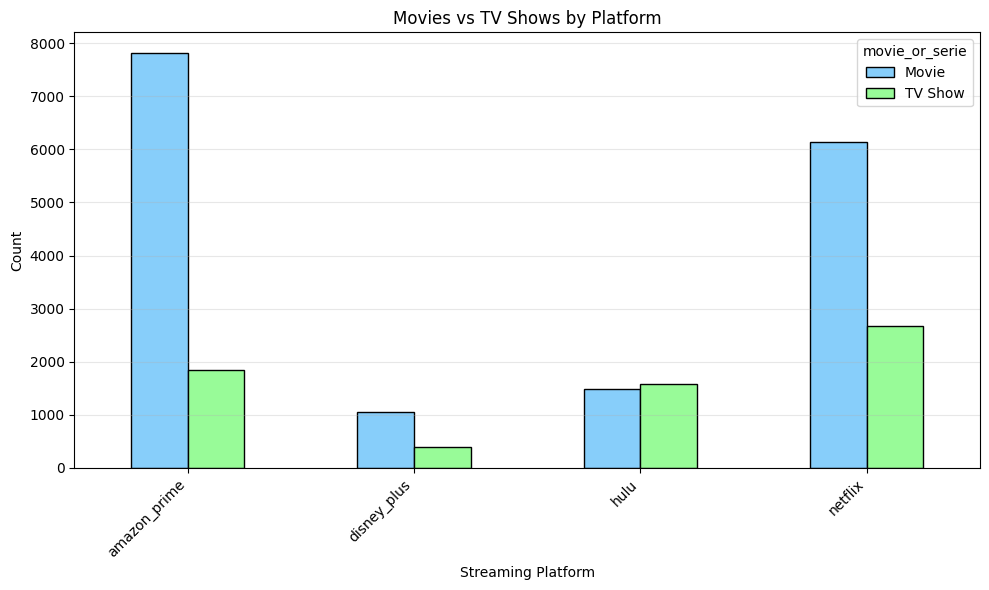

In [162]:
# movies vs tv shows by platform
counts = streaming_full.groupby(["channel_streaming", "movie_or_serie"]).size().unstack()
ax = counts.plot(kind="bar", figsize=(10,6), color=["lightskyblue", "palegreen"], edgecolor='black')
plt.xlabel("Streaming Platform")
plt.ylabel("Count")
plt.title("Movies vs TV Shows by Platform")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: Amazon Prime, Disney+, and Netflix all have more movies than TV shows. They each have more than two times the number of movies than TV shows. Hulu is the only streaming service with more TV shows than movies. 

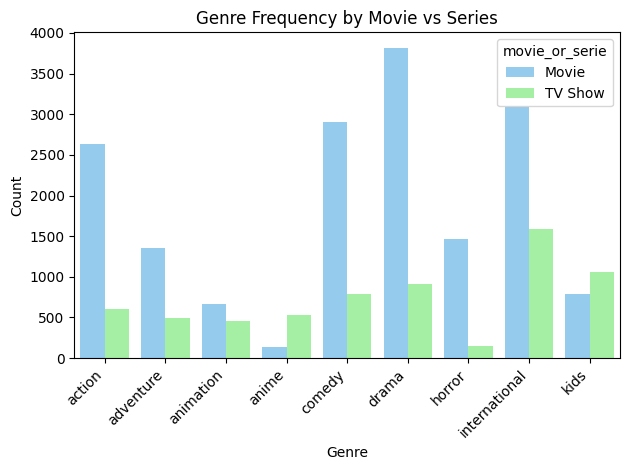

In [161]:
#format data to long format
long_df = streaming_full.melt(
    id_vars=["movie_or_serie"],
    value_vars=genres,
    var_name="Genre",
    value_name="Has_Genre")

#subset only observations that are 1 (binary variables)
long_df = long_df[long_df["Has_Genre"] == 1]

#create df of frequencies
count_df = (
    long_df
    .groupby(["Genre", "movie_or_serie"])
    .size()
    .reset_index(name="Count"))

#create color pallete to match other graphs
palette = {
    "Movie": "lightskyblue",
    "TV Show": "palegreen"}

#create grouped bar chart of movie or series by genre
sns.barplot(
    data=count_df,
    x="Genre",
    y="Count",
    hue="movie_or_serie",
    palette=palette)

plt.xticks(rotation=45, ha="right")
plt.title("Genre Frequency by Movie vs Series")
plt.tight_layout()
plt.show()

**Interpretation**: The anime and kids genres have more TV shows than movies. All the other genres have more movies than TV shows. 

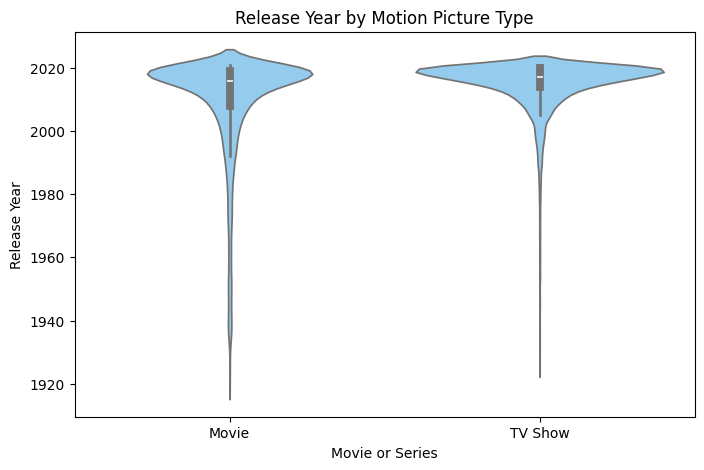

Group means:
movie_or_serie
Movie      2009.224562
TV Show    2014.823845
Name: release_year, dtype: float64


In [12]:
#Side by side violin  plots for release year
plt.figure(figsize=(8, 5))
sns.violinplot(data=streaming_full, x='movie_or_serie', y='release_year', color="lightskyblue")
plt.title('Release Year by Motion Picture Type')
plt.ylabel('Release Year')
plt.xlabel("Movie or Series")
plt.show()

#average release year for movies vs series
means = streaming_full.groupby('movie_or_serie')['release_year'].mean()
print("Group means:")
print(means)

**Interpretation**: The distribution of release year is similar for both movies and series. They are both left skewed. Movies have a more variable spread with a range of 1920-2021 and a mean release date of 2009. TV shows have a slightly smaller range from 1925-2021, with the majority of the observations having a more recent release year, the average being 2015.

### **Documentation**

The first research question explores the relationship between genre and streaming platform. Thus, we created a grouped bar chart of genre distribution by streaming service to visualize the frequencies of each streaming service for each genre. Then, we explored which streaming services had the highest frequency for each of the genres using a bar chart. These graphs allowed us to infer that there appears to be a relationship between genre and streaming platform due to the uneven distributions. The second research question explored the relationship between streaming services and movies or series. So, we created a grouped bar chart with the frequencies of movies and TV shows for each streaming service. This allowed us to visualize the distribution of movie or series across the different platforms. From our graphs we determined that there appears to be a relationship between movie or series and streaming platform due to the unequal distributions. The third research question explores how movies and series are related to the other variables in the dataset. Consequently, we created a grouped bar chart to show the distribution of movie or series for each of the genres in the dataset. Finally, we created side-by-side violin plots to depict the distribution of movie or series by release year. Similarly, we determined that movies and TV shows seem to have unique identifers due to the unequal distributions across the different platform and genres.

## **Comparative Analysis**

In [ ]:
#frequency table of each genre for each streaming service
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
print("Genre Frequency per Streaming Service:")
print("=" * 75)
print(genre_table)

Genre Frequency per Streaming Service:
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime         1657    2099        259        547     80   3687   
disney_plus             0     526          0        542      4    134   
hulu                  555     667        556         37    329    907   
netflix              1027     399       1027          0    247      0   

                   international  kids  horror  
channel_streaming                               
amazon_prime                 355  1085     875  
disney_plus                    0   141       0  
hulu                         216   162     304  
netflix                     4103   451     432  


**Interpretation:** For the first set of comparisons, we split the data by streaming service. This table shoes the frequency of each genre by the different streaming serivces. The table shoes that Disney Plus is missing obervations for the action, adventure, international, and horror genres. Netflix is missing observations for the animation and drama genres. Amazon Print and Hulu have observations for all of the genres. Amazon Prime has the most observations for the the mjority of the genres, including action, comedy, animation, drama, kids, and horror. 

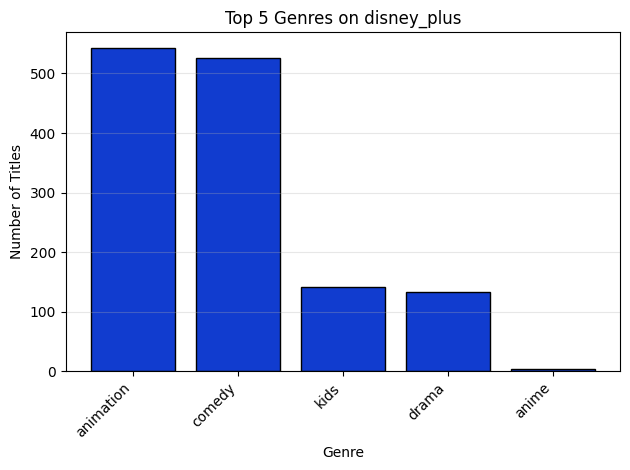

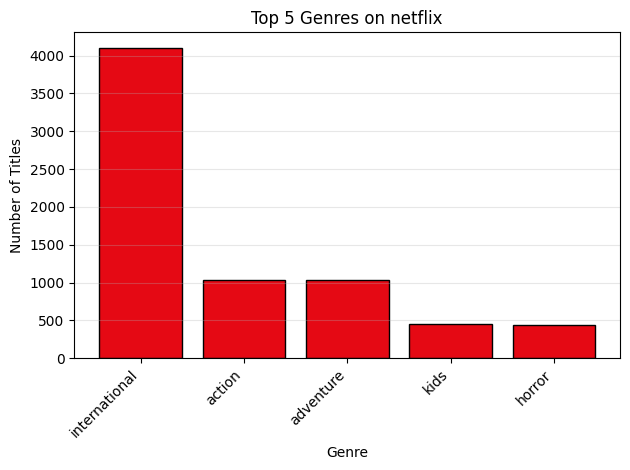

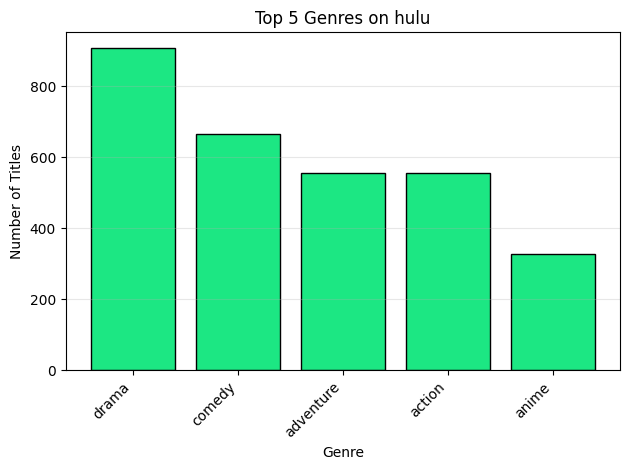

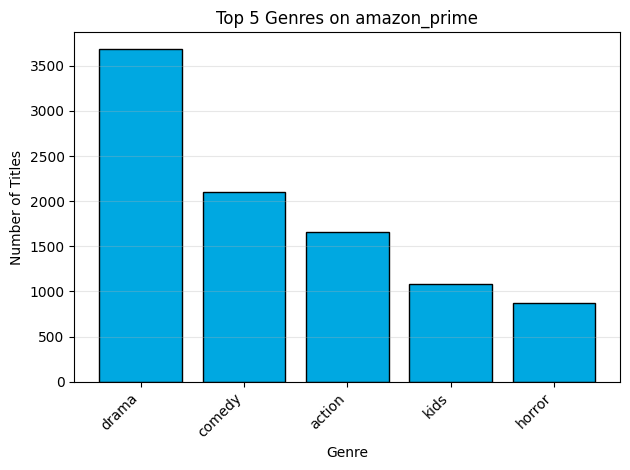

In [130]:
# identify genre columns
non_genre_cols = ["movie_or_serie", "title", "release_year",
                  "duration_seconds", "channel_streaming"]
genre_cols = [col for col in streaming_full.columns if col not in non_genre_cols]

# sum genres by platform
genre_by_platform = streaming_full.groupby("channel_streaming")[genre_cols].sum()

# get list of platforms
platforms = streaming_full["channel_streaming"].unique()

# create a color palette (colors based on the platform main brand colors)
color_palette = {
    "netflix": "#E50914",
    "disney_plus": "#113CCF",
    "amazon_prime": "#00A8E1",
    "hulu": "#1CE783"
}

# create one plot per platform showing the top 5 genres per platform
for platform in platforms:
    
    # filter platform
    platform_df = streaming_full[streaming_full["channel_streaming"] == platform]
    
    # sum genres for that platform
    genre_totals = platform_df[genre_cols].sum().sort_values(ascending=False).head(5)

    # plot
    plt.figure()
    plt.bar(genre_totals.index, genre_totals.values, color=color_palette[platform], edgecolor="black")
    plt.title(f"Top 5 Genres on {platform}")
    plt.xlabel("Genre")
    plt.ylabel("Number of Titles")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

**Interpretation**: These bar charts depict the top five genres for each of the different streaming services. None of the streaming services have the same top 5 genres. The genres of action, kids, drama, and comedy are the most popular because they are in the top 5 across three of the different streaming services. All of the genres are represented at least one across the five different platforms most common genres. 

In [ ]:
#proportion of each movie or tv show for each streaming service
print("\nMovie or Streaming distributiton for Streaming Service:")
print("=" * 55)
proportions_movie_show = (streaming_full.groupby("channel_streaming")["movie_or_serie"].value_counts(normalize=True).unstack(fill_value=0))
print(proportions_movie_show)


Movie or Streaming distributiton for Streaming Service:
movie_or_serie        Movie   TV Show
channel_streaming                    
amazon_prime       0.808233  0.191767
disney_plus        0.725517  0.274483
hulu               0.482916  0.517084
netflix            0.696151  0.303849


**Interpretation:** This table shows the distribution of movies versus TV shows for each streaming service. Amazon Prime, Disney Plus, and Netflix all have a higher percentage of movies than TV shows. Hulu is the only streaming service with more TV shows than movies; however, the distribution is almost evenly split with 52% TV shows and 48% movies. Amazon Prime has the largest difference in percentages with 81% movies and only 19% TV shows.

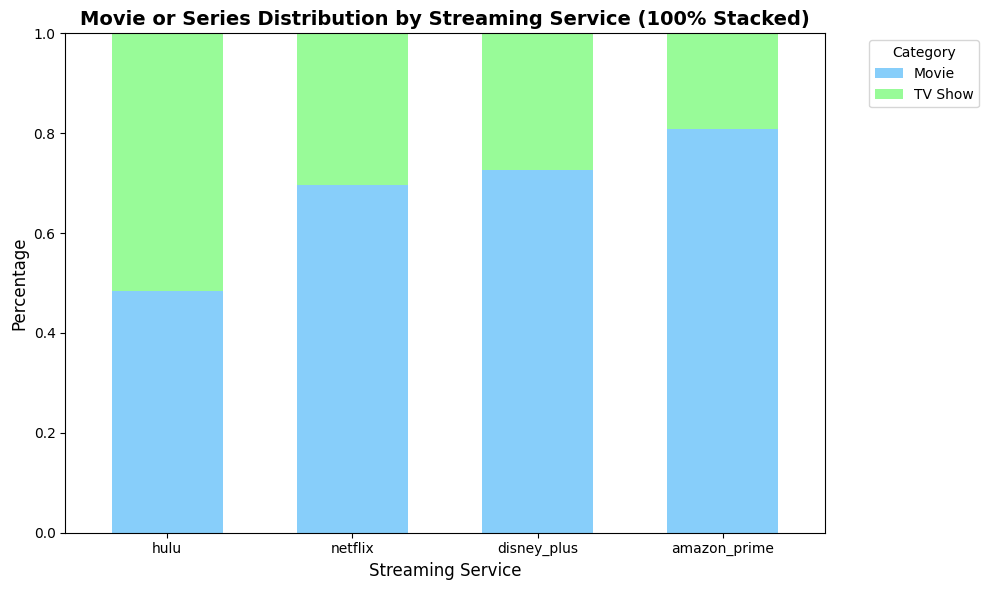

In [ ]:
#stacked bar chart of proportions for each
proportions_df = pd.DataFrame(proportions_movie_show)
proportions_df = proportions_df.sort_values(by='Movie', ascending=True)

# Create 100% stacked bar plot
ax = proportions_df.plot(kind='bar', stacked=True, figsize=(10, 6), width=0.6, color=['lightskyblue', 'palegreen'])
plt.xlabel('Streaming Service', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.title('Movie or Series Distribution by Streaming Service (100% Stacked)', fontsize=14, fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Interpretation**: This percent stacked bar chart visualizes the information from the table created above for easy interpreation. It is sorted so that one can quickly see that Amazon prime has the highest percentage of movies followed by Disney Plus, Netflix, and Hulu. 

In [ ]:
#mean release year for each genre for movies or tv shows
movies = streaming_full[streaming_full["movie_or_serie"]=="Movie"]
series = streaming_full[streaming_full["movie_or_serie"]=="TV Show"]

#frequency table of each genre for each streaming service for movies and series
genre_movie = movies.groupby("channel_streaming")["release_year"].mean()
genre_series = series.groupby("channel_streaming")["release_year"].mean()

print("Average Release Year for Movies")
print("=" * 35)
print(genre_movie)

print("\nAverage Release Year for Series")
print("=" * 35)
print(genre_series)

Average Release Year for Movies
channel_streaming
amazon_prime    2006.869977
disney_plus     1999.230989
hulu            2012.607143
netflix         2013.121514
Name: release_year, dtype: float64

Average Release Year for Series
channel_streaming
amazon_prime    2014.545307
disney_plus     2013.296482
hulu            2012.530522
netflix         2016.605755
Name: release_year, dtype: float64


**Interpretation:**  For the second set of comparisons, we subset the data by movie or series. This table shows the average release year for each streaming service for movies versus TV shows. For movies, Netflix has the most recent average release date at 2013. Disney Plus has the oldest average release date at 1999. For TV shows, Netflix still has the most recent average release year at 2016. However, Hulu has the oldest average release year at 2012. Overall, the average release years for the TV shows (which range from 2012-2016) are more recent than the average release years for movies (which range from 1999-2013). 

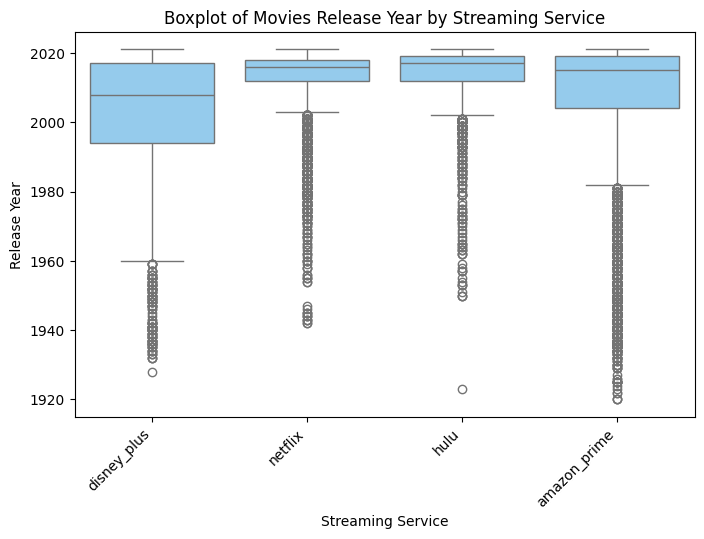

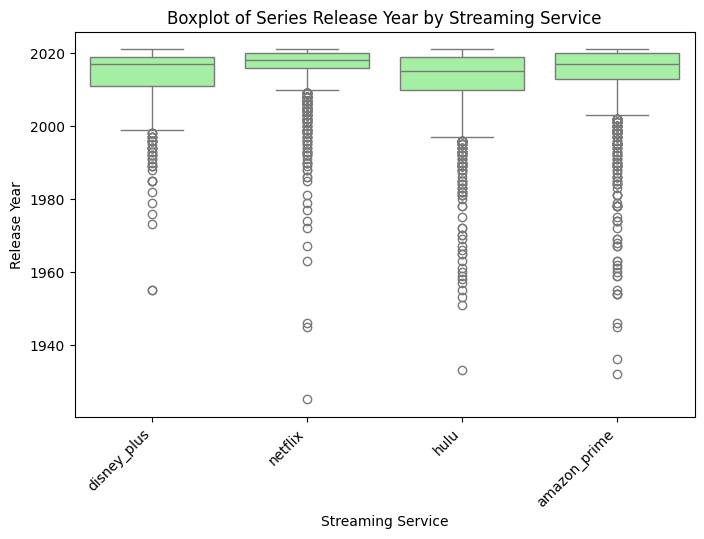

In [ ]:
#create function that will produce side-by-side boxplots
def sideBoxplots(df, x_var, y_var, title, y_axis, x_axis, color = "lightskyblue"):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=x_var, y=y_var, color = color)
    plt.title(title)
    plt.ylabel(y_axis)
    plt.xlabel(x_axis)
    plt.xticks(rotation=45, ha="right")
    plt.show()

#side by side boxplots of release year by streaming service
sideBoxplots(movies, "channel_streaming", "release_year", "Boxplot of Movies Release Year by Streaming Service", "Release Year", "Streaming Service")
sideBoxplots(series, "channel_streaming", "release_year", "Boxplot of Series Release Year by Streaming Service", "Release Year", "Streaming Service", color = "palegreen")

**Interpretation:** These side-by-side boxplots show the distribution of release year for each of the different platforms for movies and TV shows. They visualize the distributions of the tables created above with the average release years. For movies, Disney Plus has the largest IQR, but Amazon Prime has the largest range. The distributions of release years for Netflix and Hulu are very similar. For TV shows, the distributions of release years appear to be more similar than compared to movies. Netflix has the largest range and the smallest IQR. For both movies and TV shows, all streaming services have IQRs concentrated around or before the 2000s for both movies and TV shows with several outliers spreading from the 1920s-1960 on average.

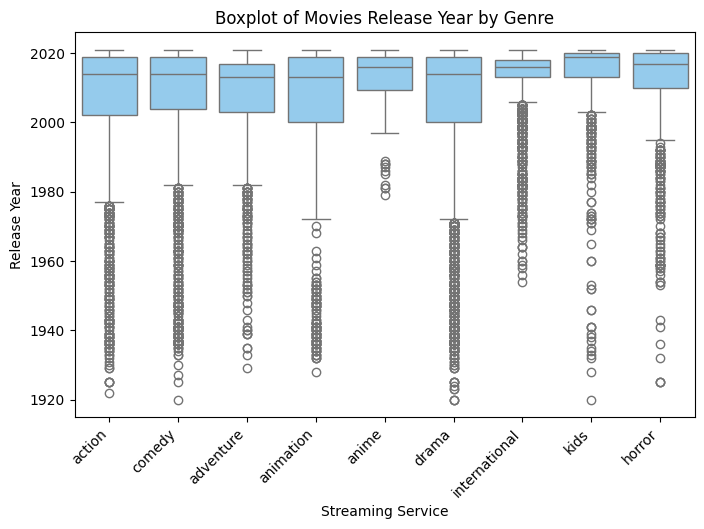

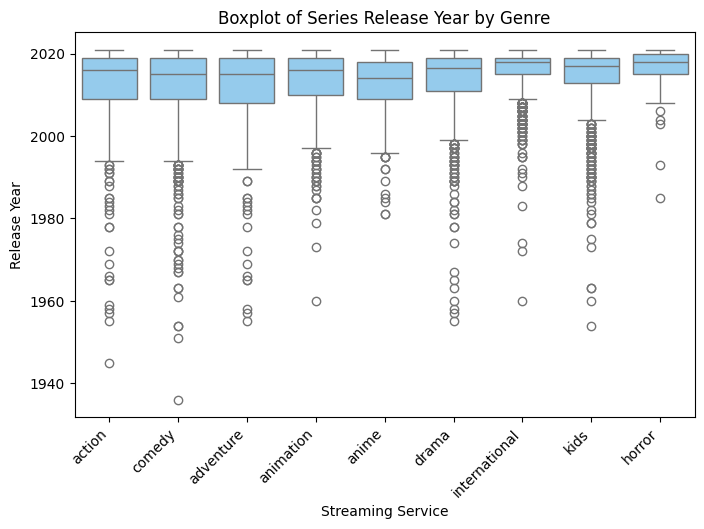

In [ ]:
#prepare data for for loop
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']
dfs = [movies, series]
df_names = ["Movies", "Series"]

#iterate through the dataframes to create side-by-side boxplots of release year by genre
for i, df in enumerate(dfs):
    df_long = df.melt(
        id_vars=['release_year'],
        value_vars=genres,
        var_name='genre',
        value_name='is_genre')

    # Keep only rows where the genre applies (value == 1)
    df_long = df_long[df_long['is_genre'] == 1]

    sideBoxplots(df_long, "genre", "release_year", f"Boxplot of {df_names[i]} Release Year by Genre", "Release Year", "Streaming Service")

**Interpretation:** These side-by-side boxplots show the distribution of release year by genre for movies and TV shows. For movies, the anime genre clearly has the shortest range.The international genre has the smallest IQR, and the drama and animation genres have the largest IQR. All the boxes of the boxplots are above the 2000s, and all genres have outliers below the bottom whisker. For TV shows, all the IQRS appear very similar except for the international genre which is smaller than the others. All the boxes of the boxplot are above 2008, and all genres have outliers below the bottom whisker. 

### **Documentation**

For the comparative analysis, we explored two different subsets of out data. First, we focused on the data when it was split between the four different streaming services. Then, we focused on the data when it was sectioned into movies versus TV shows. 

For the analysis of the different streaming services, we compared genre distribution and movie/series distribution for each platform. First we created a frequency table of streaming service by platform. Then, we visualized these results by creating four bar charts, where each bar chart represented the top five genres for each of the streaming platforms. These numerical and graphical representations helped us to further explore our first research question which focused on genre distribution and streaming platforms. Since the top five genres were different for each of the streaming platforms, we can infer there is an association between the two variables. Next, we explored the relationship between the distribution of movies and TV shows across the different streaming platforms. We created a numerical representation through a proportion table that showed the proportion of movies and TV shows for each streaming platform. Then, we represented those findings visually through percent stacked bar charts. This analysis coincided with our second research question that explored the relationship between the streaming platform and the distribution of movies versus TV shows. We found that the proportions of movies and TV shows for the different streaming platforms were quite different. This implied that there was a relationship between movie/TV show and streaming platform. 

Next, we subset our data between movies and TV shows. We explored the average release year across the different streaming services for movies versus TV shows. We presented our findings numerically by calculating the mean release year for each of the streaming platforms seperately for movies and TV shows. Then, we represented our findings visually though side-by-side boxplots that showed the distribution of release year for each of the streaming services for movies and TV shows. Lastly, we created side-by-side boxplots that showed the distribution of release year for each of the genres for movies and TV shows. This comparative analysis between movies and TV shows allowed us to investigate our third research question which focused on the relationship between movie and TV show across the different variables in our dataset. We found that movies tended to have larger IRQs across streaming services and genres as compared to TV shows which implied that there is a relationship between movies and TV shows across different variables. 

## **Multivariate Analysis**

In [43]:
# 1. Are there significant differences in genre distribution across streaming platforms?
print("RQ1 - PIVOT TABLE: Genre Counts by Platform and Content Type")
print("=" * 60)
for content_type in ["Movie", "TV Show"]:
    subset = streaming_full[streaming_full["movie_or_serie"] == content_type]
    pivot = subset.groupby("channel_streaming")[genres].sum()
    print(f"\n--- {content_type}s ---")
    print(pivot)

RQ1 - PIVOT TABLE: Genre Counts by Platform and Content Type

--- Movies ---
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime         1502    1821        230        279     29   3206   
disney_plus             0     407          0        381      0    121   
hulu                  273     337        260          5     35    489   
netflix               859     343        859          0     71      0   

                   international  kids  horror  
channel_streaming                               
amazon_prime                 284   679     845  
disney_plus                    0    39       0  
hulu                          55    67     258  
netflix                     2752     0     357  

--- TV Shows ---
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime          155 

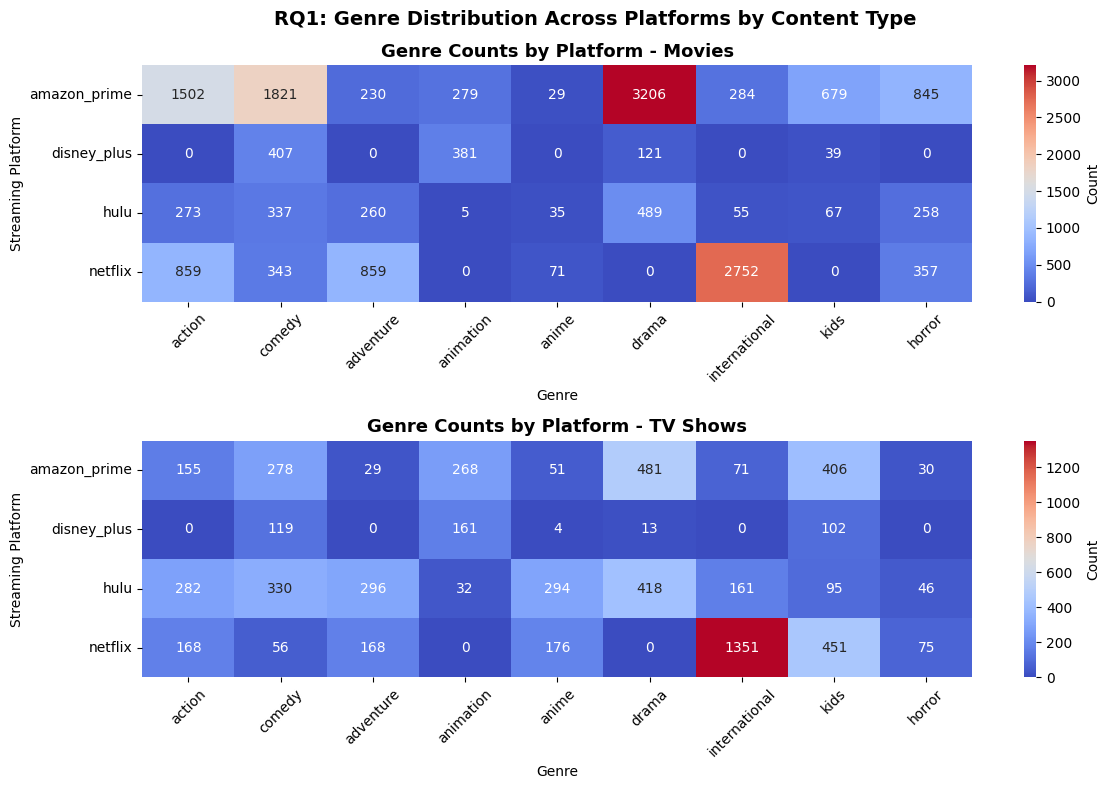

In [ ]:
# Heatmap: genre x platform, split by content type
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, content_type in zip(axes, ["Movie", "TV Show"]):
    subset = streaming_full[streaming_full["movie_or_serie"] == content_type]
    pivot = subset.groupby("channel_streaming")[genres].sum()
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm", ax=ax, cbar_kws={"label": "Count"})
    ax.set_title(f"Genre Counts by Platform - {content_type}s", fontsize=13, fontweight="bold")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Streaming Platform")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("RQ1: Genre Distribution Across Platforms by Content Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** The genre distribution across platforms and content type (movie vs TV show) was shown through a pivot table and heatmap. From the distribution, we can see that Disney+ has many genres with 0 counts, and the majority of content available on the platform is family-oriented with genres such as comedy, animation, and kids. For Amazon Prime, it's heavily concentrated in movies in contrast to TV shows, especially for the genre, drama. For Netflix, we can see that it's heavily contentrated in international content for both movies and TV shows, which show Netflix's investments into more international content in contrast to other platforms. Additionally, from the heatmap, we can see clear outliers (the reddish or dark red cells), which indicate heavy concentration in those genres for certain platforms (ie drama for Amazon Prime and international for Netflix.).

In [41]:
# 2. Is there a difference between the platforms in their balance between movies and television shows?
print("RQ2 - CROSS-TABULATION: Content Type by Platform")
print("=" * 60)
ct = pd.crosstab(
    streaming_full["channel_streaming"],
    streaming_full["movie_or_serie"],
    margins=True,
    margins_name="Total"
)
print(ct)

print("\nCOLUMN PROPORTIONS: Content Type within each Platform")
print("=" * 60)
ct_prop = (
    pd.crosstab(
        streaming_full["channel_streaming"],
        streaming_full["movie_or_serie"],
        normalize="index"
    ) * 100
)
print(ct_prop.round(2))

RQ2 - CROSS-TABULATION: Content Type by Platform
movie_or_serie     Movie  TV Show  Total
channel_streaming                       
amazon_prime        7814     1854   9668
disney_plus         1052      398   1450
hulu                1484     1589   3073
netflix             6131     2676   8807
Total              16481     6517  22998

COLUMN PROPORTIONS: Content Type within each Platform
movie_or_serie     Movie  TV Show
channel_streaming                
amazon_prime       80.82    19.18
disney_plus        72.55    27.45
hulu               48.29    51.71
netflix            69.62    30.38


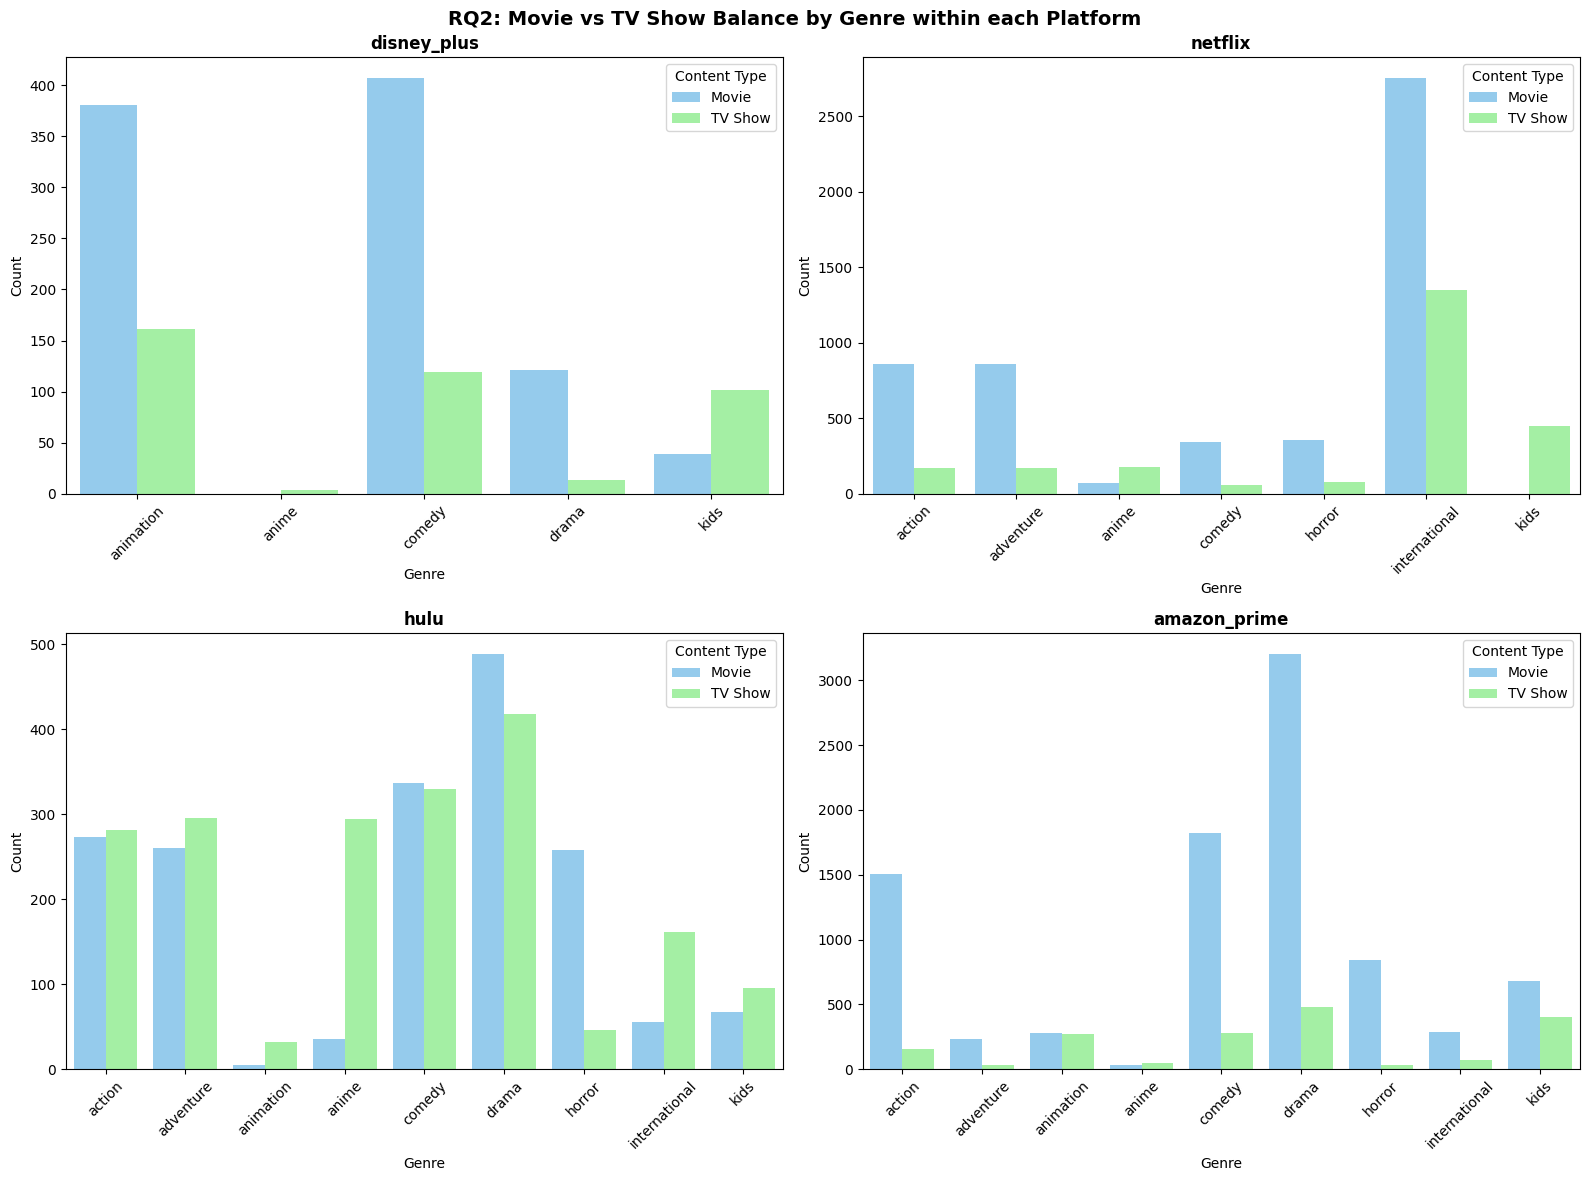

In [42]:
# grouped bar chart: genre x content type for each platform
df = streaming_full.melt(
    id_vars=["channel_streaming", "movie_or_serie"],
    value_vars=genres,
    var_name="Genre",
    value_name="Has_Genre"
)
df = df[df["Has_Genre"] == 1]

count_df = (
    df.groupby(["channel_streaming", "Genre", "movie_or_serie"]).size().reset_index(name="Count")
)

platforms = streaming_full["channel_streaming"].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, platform in zip(axes, platforms):
    subset = count_df[count_df["channel_streaming"] == platform]
    sns.barplot(data=subset, x="Genre", y="Count", hue="movie_or_serie", palette={"Movie": "lightskyblue", "TV Show": "palegreen"}, ax=ax)
    ax.set_title(f"{platform}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Content Type")

plt.suptitle("RQ2: Movie vs TV Show Balance by Genre within each Platform", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** For RQ2, we used cross-tabulation and column proportions to take an in-depth look into platform x content type x genre. For example, Hulu has the most balanced distribution between movies and TV shows (48% vs 52%). It's also the only platform where there are more TV shows than movies, while the other three platforms have a greater proportion of movies over TV shows. Amazon Prime has the greatest imbalance among the four platforms, with 81% of its content consisting of movies and only 19% of the content being TV Shows.

In [58]:
# 3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?
print("RQ3 - PIVOT TABLE: Mean Release Year by Platform and Content Type")
print("=" * 60)
pivot_year = streaming_full.pivot_table(
    values="release_year", index="channel_streaming", columns="movie_or_serie", aggfunc="mean"
)
print(pivot_year.round(2))

RQ3 - PIVOT TABLE: Mean Release Year by Platform and Content Type
movie_or_serie       Movie  TV Show
channel_streaming                  
amazon_prime       2006.87  2014.55
disney_plus        1999.23  2013.30
hulu               2012.61  2012.53
netflix            2013.12  2016.61


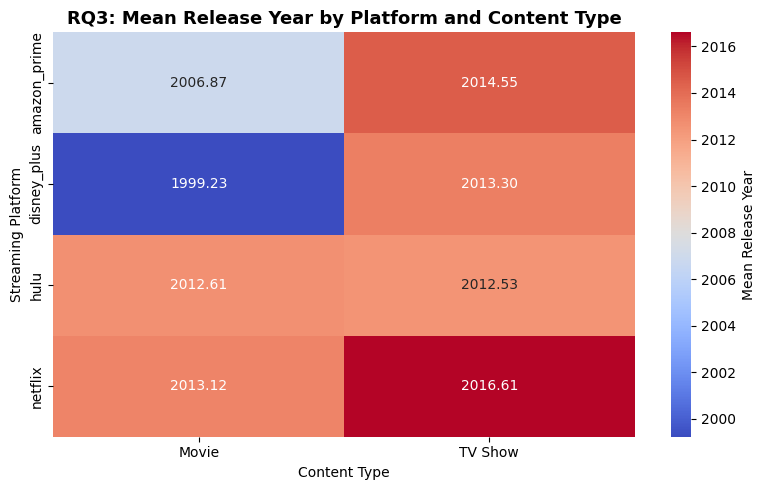

In [59]:
# Heatmaps: genre x platform, split by content type
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_year, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Mean Release Year"})
plt.title("RQ3: Mean Release Year by Platform and Content Type", fontsize=13, fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Streaming Platform")
plt.tight_layout()
plt.show()

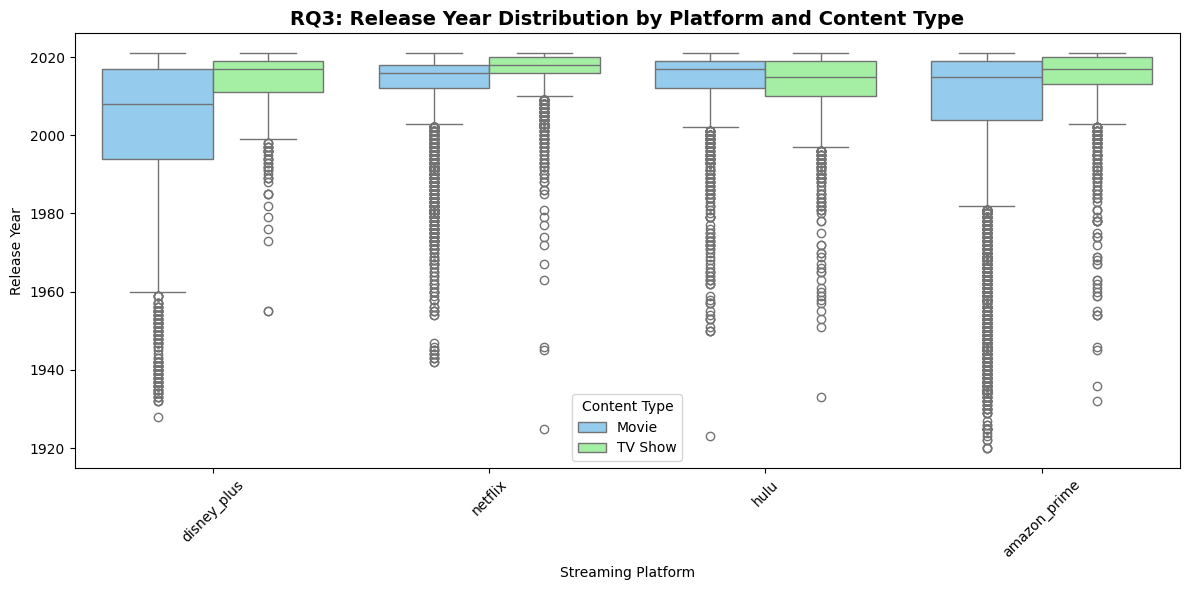

In [61]:
# Boxplot: release year x content type x platform 
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=streaming_full, x="channel_streaming", y="release_year", hue="movie_or_serie", palette={"Movie": "lightskyblue", "TV Show": "palegreen"} 
)
plt.title("RQ3: Release Year Distribution by Platform and Content Type", fontsize=14, fontweight="bold")
plt.xlabel("Streaming Platform")
plt.ylabel("Release Year")
plt.legend(title="Content Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** For RQ3, we looked at the relationship between the release year, platform, and content type using a pivot table, heatmap, and boxplot. Based on the heatmap, we can see that TV shows have a higher average release year than movies across all platforms. This suggests that streaming services add older movies and newer TV shows. This also indicates the increasing popularity of TV shows over the past couple of years with more platforms creating their own original TV shows. Overall, the distributions of release years for each platform seems to be similar. However, from the heatmap and boxplot, we can see that Disney+ and Amazon Prime seems to have the largest range in release years with movies and TV shows from the 1900s.

### **Documentation**

For the multivariate analysis, we examined relationships among three or more variables, building on the findings from our earlier sections.

For the first research question, we added content type as a third variable to explore whether genre distribution across platforms differed for movies versus TV shows separately. We created two pivot tables of genre counts broken down by both platform and content type, then visualized these results using two heatmaps — one for movies and one for TV shows — where color intensity represented the count for each platform-genre combination. This allowed us to determine whether the genre differences we observed across platforms were consistent across content types or driven primarily by one of them.
 
For the second research question, we extended the platform-by-content-type analysis to include genre as a third variable. We created a cross-tabulation of content type by platform with both raw counts and row proportions to quantify the Movie/TV Show balance within each platform. Then, we visualized these relationships through a set of four grouped bar charts (one per platform) where each chart showed the count of movies versus TV shows broken down by genre. These visualizations allowed us to see not just that platforms differ in their Movie/TV Show balance, but how that imbalance manifests differently across genres within each platform.

For the third research question, we examined the relationship between release year, platform, and content type. We created a pivot table of mean release year indexed by platform and content type, then visualized it as a heatmap to make platform-by-content-type
differences in catalog age easy to compare. We also created a grouped boxplot with platform on the x-axis, release year on the y-axis, and content type as the hue, which showed the full distribution of release year across all platform and content type
combinations. Together, these analyses allowed us to assess whether the release year difference between movies and TV shows found in the inferential statistics held consistently across all four platforms.

## **Synthesis**

The various analyses conducted during this project yielded meaningful insights for all three of our research questions. Our dataset was composed of mainly categorical variables, which shaped the analytical choices we made throughout each section. For the descriptive statistics, we relied on frequency counts and proportions to understand the distributions of genres, streaming platforms, and content types. This showed us that the data was unevenly distributed. For example, Amazon Prime had the most content, where drama was the dominant genre, and movies outnumbered TV shows by a ratio of 2.5 to 1. These early observations informed the direction of our subsequent analyses.

For our first research question, the evidence from every section pointed to the same conclusion that there is a significant difference in genre distribution across streaming platforms. The chi-square test confirmed the association was statistically significant, the grouped bar charts showed that each platform had a distinct genre distribution, and the multivariate heatmaps revealed that these differences existed for both movies and TV shows. Disney+ stood out as the most concentrated platform, with zero representation in five of the nine genres, while Amazon Prime had the broadest catalog and dominated six genres by count. 

For our second research question, we found that Hulu was a clear outlier. While Amazon Prime, Netflix, and Disney+ all carried more than twice as many movies as TV shows, Hulu was the only platform where TV shows outnumbered movies. The chi-square test confirmed this difference was statistically significant, and the multivariate grouped bar charts showed that this imbalance extended across
genres within each platform as well.

For our third research question, we found that release year is a meaningful distinguishing attribute. Movies had an average release year of approximately 2009, while TV shows had an average release year of approximately 2015. The t-test confirmed this difference was statistically significant. The multivariate analysis further showed that this pattern was consistent across all four streaming platforms, with TV shows having a higher average release year than movies on every platform.

Overall, the combination of the datasets has provided added value in terms of insights or capabilities that would not be possible with the individual datasets to answer these questions. By merging the datasets, we could identify various insights into the different platforms, such as Hulu being structurally distinct from the other three platforms, observing Disney+'s genre gaps, and comparing how each platform balances its content type distribution.

### **Documentation**

For the synthesis section, we brought together the findings from each section of the analysis to directly address our three research questions. We outlined how the descriptive statistics established the baseline distributions, how the inferential tests confirmed the
statistical significance of the relationships we observed, and how the graphical, comparative, and multivariate analyses added depth and specificity to those findings. We also discussed the added value of merging the datasets we found, which provided added insights into our data and findings. It was also interesting to see how each section built upon the previous sections to produce a coherent set of conclusions to our three research questions.

## **Reflection**

The analysis section of the project posed many challenges but yeilded fruitful results. The dataset that we analyzed composed mainly of categorical variables, which challenged us in our ability to make appropriate graphs and numerical summaries. For the descriptive statistics we had to rely on values counts, and we had to determine how to properly group or data so that the frequencies we generated would be representative of our research questions. For our inferential statistics, we similarly had to perform tests that were appropriate for categorical data. So, we did two chi-squared tests (and a t-test for our quantitative variable). The graphical analysis section was quite enjoyable. It allowed us to explore some creativity in the different ways we could graphically represent the data. For instance, in lecture, we learned how to produce side-by-side boxplots, but when we created the boxplots for release year by movie or TV show, we found that it was difficult to interpret due to several outliers. So, we opted to find a different type of graph that better illustrated our data, which is why we created side-by-side violin plots. Furthermore, the graphical analysis section challeged us to think about how we wanted our dataset represented. For example, when we created the grouped bar charts of movie or TV show by genre, we had to transform our data from wide format to long format to represent the genres correctly. 

The final two sections, the comparative analysis and the multivariate analysis were the two most challenging sections. For the comparative analysis we had to determine how we wanted to subset our data and how those subsets would best reflect our reseach questions. Ultimately, we decided on two different subsets--one that focused on each streaming platform as a subset and one that focused on movies and TV shows as different subsets. Since our first and second research questions emphasize the different streaming platforms, and our third research question emphasizes movies versus TV shows, we determined those were appropriate subsets. Then, we wanted to complete the comparative analysis by producing a numerical and graphical representation for each of our subsets and their respective research question. This challenged us to determine how we wanted to transform our numerical summaries into appropriate graphical representations. We ran into a similar challenge for the multivariate analysis section. We had to determine the best way to produce numerical and visual represenations of three or more variables in a manner that was not too complex. We wanted our graphical displays to be easily interpretable and not too crowded with information while still relaying the necessary information. Thus, for instance, we chose to represent our tables through heat maps, which draw the readers' eyes to the relavent information rather than scouring a table for the highest/lowest values. Another method we chose to imploy was grouped side-by-side boxplots. This allows the reader to compare the release years of movies versus TV shows for each of the different streaming platforms in an easily interpretable way on a single graph. 

Overall, this analysis project challenged us to determine the best ways to represent our data. Whether the data was in numerical format or graphical format, we had to be very intentional about the representations we produced so that they were easily interpretable and not too complex. It was an enjoyable challenge, and it helped us to discover serveral new ways to approach data analysis. 

### **Documentation**

For the analysis section, we thoughtfully reflected on each step of the analysis journey. We outlined the difficulties we faced in creating graphs, formatting our data, and representing the data appropriately. We also relayed the pride we felt from completing the analysis and answering the research questions that we posed in part one of the project. It was a challenging journey, but the results were fruitful. 